# NYC PLUTO - Dimensionality Reduction, Part A: PCA

**Course:** Data Engineering - Unsupervised Learning Project
**University:** Bar-Ilan University, Spring 2026
**Author:** Elie Hamou

This notebook is the dedicated PCA study referenced (but deferred) by
`02_clustering/processing_and_clustering.ipynb`. It serves two deliverables:

- **Mini Project, Part A (PCA):** cumulative explained variance, choice of the
  number of components, and a judgement on whether PCA is useful for this dataset.
- **Final report, "Representation" section:** method and parameters, effect on
  clustering, effect on interpretability, advantages and limitations.

**Input:** the shared standardized clustering matrix `data/processed/X_scaled.csv`
(16 numeric features, ~682k buildings) produced by the clustering notebook. We do
**not** redo the preprocessing here - we reuse the team's canonical artifact so the
PCA analysis is consistent with the clustering pipeline.

**Outline**
1. Setup and data loading
2. Explained variance and choice of `k`
3. Component interpretation (loadings)
4. 2D visualization
5. Effect on clustering (silhouette: full space vs PCA space)
6. Discussion and conclusions

## 1. Setup and data loading

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

# Robust project-root detection, identical pattern to the clustering notebook:
# walk up from the current directory until we find data/processed/ + requirements.txt.
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root (expected data/processed/ and requirements.txt).")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)

Project root: /Users/upmem/Desktop/nyc-pluto-clustering


We load three shared artifacts written by the clustering notebook:

| File | Role here |
|---|---|
| `X_scaled.csv` | the standardized 16-feature matrix - the input to PCA |
| `X_scaled_features.csv` | the ordered feature names |
| `pluto_companion.csv` | original (un-scaled) values + `landuse`/`borough` for **blind** coloring of the projection (never fed to PCA) |

`X_scaled.csv` is row-aligned with `pluto_companion.csv` (same order, no shuffling),
so we can color PCA points by land use positionally.

In [2]:
X = pd.read_csv(PROCESSED_DIR / "X_scaled.csv")
features = X.columns.tolist()
companion = pd.read_csv(PROCESSED_DIR / "pluto_companion.csv", index_col=0)

assert len(X) == len(companion), "X_scaled and companion must be row-aligned"

print(f"Standardized clustering matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print("Features:", features)
# Sanity: a standardized matrix has column means ~0 and column std ~1.
print(f"max|mean| = {X.mean().abs().max():.2e}   mean(std) = {X.std().mean():.3f}")

Standardized clustering matrix: 682,515 rows x 16 features
Features: ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']
max|mean| = 1.89e-15   mean(std) = 1.000


## 2. Explained variance and choice of `k`

PCA finds orthogonal directions (principal components) ordered by the amount of
variance they capture. To decide how many components to keep, we fit a **full-rank**
PCA and inspect:

- the **scree plot** (variance per component) - looking for an "elbow";
- the **cumulative explained variance** - looking for the smallest `k` that crosses a
  threshold (90% / 95%).

In [3]:
# Full-rank PCA to inspect the whole spectrum.
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

# Components needed to reach common variance thresholds.
thresholds = [0.80, 0.90, 0.95, 0.99]
k_for = {t: int(np.searchsorted(cumvar, t)) + 1 for t in thresholds}
for t in thresholds:
    k = k_for[t]
    print(f"{int(t*100)}% variance -> {k:2d} components (cumulative {cumvar[k-1]*100:.2f}%)")

K90 = k_for[0.90]   # number of components retained for the clustering comparison
print(f"\nPC1 = {evr[0]*100:.1f}%   PC2 = {evr[1]*100:.1f}%   PC1+PC2 = {cumvar[1]*100:.1f}%")

80% variance ->  8 components (cumulative 82.69%)
90% variance -> 10 components (cumulative 92.19%)
95% variance -> 11 components (cumulative 95.68%)
99% variance -> 13 components (cumulative 99.00%)

PC1 = 24.5%   PC2 = 19.2%   PC1+PC2 = 43.7%


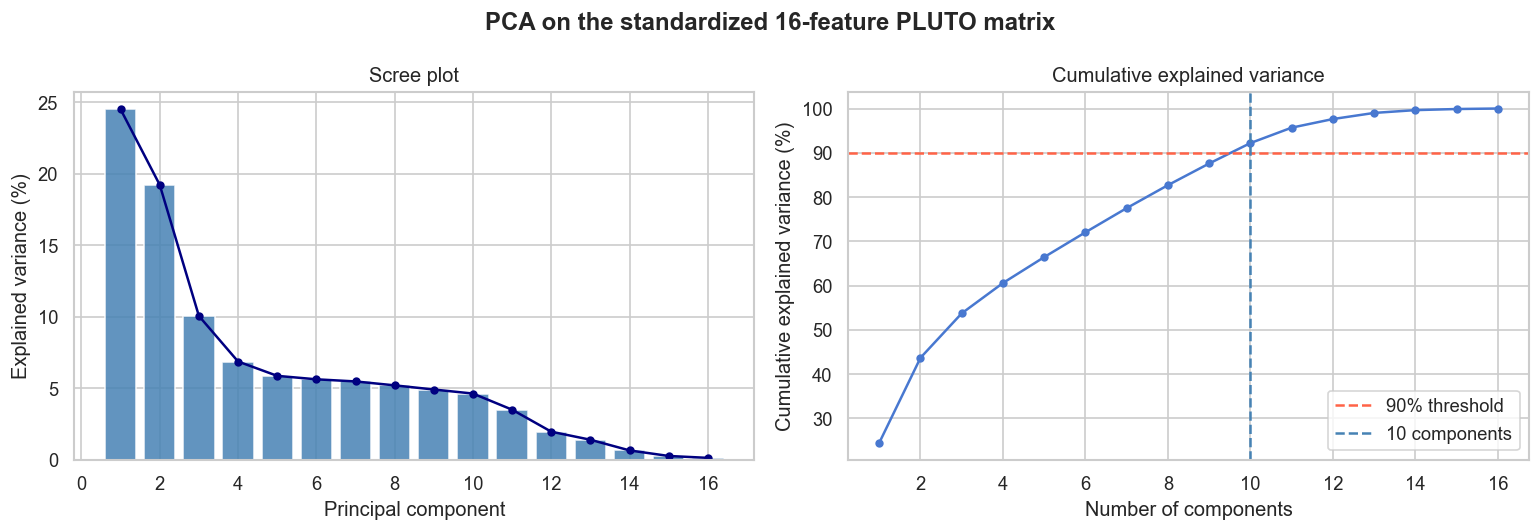

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scree plot: variance carried by each individual component.
axes[0].bar(range(1, len(evr) + 1), evr * 100, color="steelblue", alpha=0.85)
axes[0].plot(range(1, len(evr) + 1), evr * 100, color="navy", marker="o", ms=4)
axes[0].set(xlabel="Principal component", ylabel="Explained variance (%)",
            title="Scree plot")

# Cumulative explained variance with the 90% threshold marked.
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", ms=4)
axes[1].axhline(90, color="tomato", ls="--", label="90% threshold")
axes[1].axvline(K90, color="steelblue", ls="--", label=f"{K90} components")
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance (%)",
            title="Cumulative explained variance")
axes[1].legend()

fig.suptitle("PCA on the standardized 16-feature PLUTO matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pca_scree_cumulative.png", bbox_inches="tight")
plt.show()

**Reading the variance.**

- PC1 carries ~24% and PC2 ~19% of the variance; the decay afterwards is **gradual,
  with no sharp elbow**. The data is not dominated by one or two directions.
- Reaching 90% of the variance requires **10 of the 16 components** (95% needs 11).
  In other words, PCA offers only **modest compression** on this feature set - very
  different from the textbook digits example (784 -> 30). This is expected: the team's
  feature selection already removed redundant/administrative columns, so the 16
  remaining features are individually informative.
- **Consequence:** on PLUTO, the value of PCA is mainly **decorrelation, mild
  denoising, and 2D visualization** - not strong compression.

## 3. Component interpretation (loadings)

A principal component is a weighted combination of the original features. The weights
("loadings") tell us *what each component means*. We display the loadings of the first
six components as a heatmap, then list the dominant features of PC1-PC3.

> Note: the **sign** of a component is arbitrary (a component and its negative are
> equivalent), so we interpret each axis as a *contrast* between groups of features.

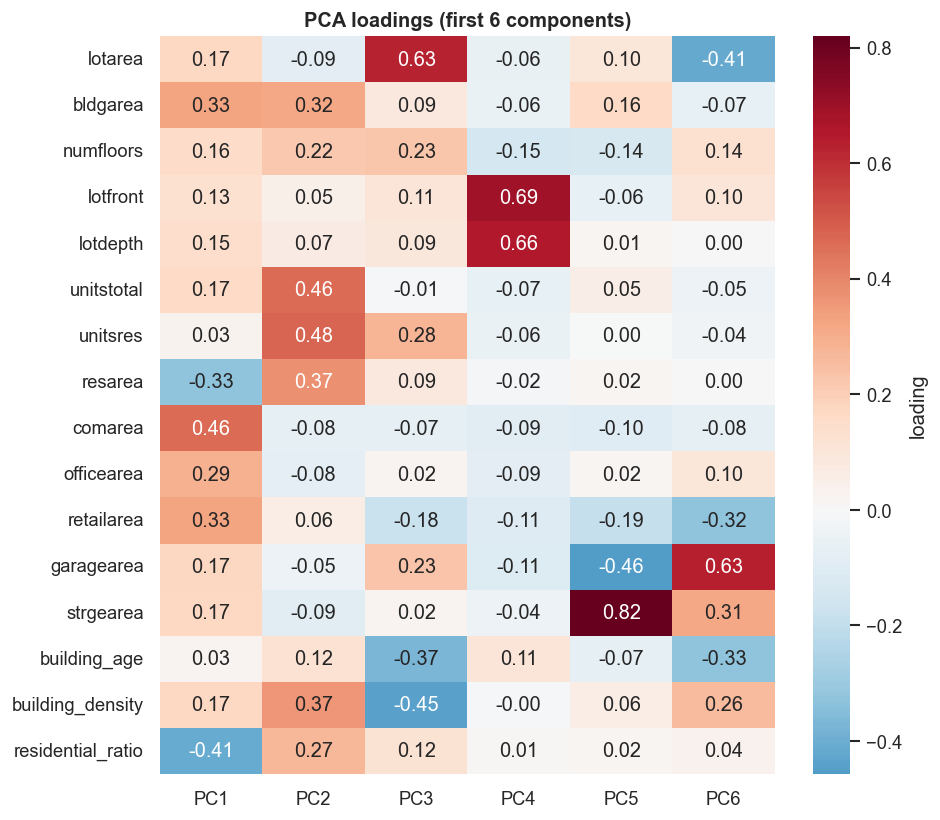


PC1 (24.5% variance) - dominant features:
comarea              0.464
residential_ratio   -0.409
resarea             -0.329
retailarea           0.329
bldgarea             0.328

PC2 (19.2% variance) - dominant features:
unitsres            0.476
unitstotal          0.464
resarea             0.374
building_density    0.365
bldgarea            0.321

PC3 (10.0% variance) - dominant features:
lotarea             0.626
building_density   -0.446
building_age       -0.371
unitsres            0.278
garagearea          0.232


In [5]:
n_show = 6
loadings = pd.DataFrame(
    pca_full.components_[:n_show].T,
    index=features,
    columns=[f"PC{i+1}" for i in range(n_show)],
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            cbar_kws={"label": "loading"}, ax=ax)
ax.set_title(f"PCA loadings (first {n_show} components)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pca_loadings_heatmap.png", bbox_inches="tight")
plt.show()

# Dominant features per component, ranked by absolute loading.
for pc in ["PC1", "PC2", "PC3"]:
    top = loadings[pc].abs().sort_values(ascending=False).head(5).index
    print(f"\n{pc} ({evr[int(pc[2:]) - 1] * 100:.1f}% variance) - dominant features:")
    print(loadings.loc[top, pc].round(3).to_string())

**What the components mean.**

- **PC1 - residential <-> commercial contrast.** Strong positive loadings on `comarea`,
  `retailarea`, `officearea`, `bldgarea`; strong negative on `residential_ratio` and
  `resarea`. PC1 separates **commercial / non-residential** lots from **residential** ones.
- **PC2 - intensity of residential development.** High loadings on `unitsres`,
  `unitstotal`, `resarea`, `building_density`, `bldgarea`: large, dense, multi-unit
  residential buildings sit at one end, small low-density lots at the other.
- **PC3 - large open lots vs dense/old buildings.** `lotarea` loads positively while
  `building_density` and `building_age` load negatively: big sparsely-built lots vs
  compact older structures.

These axes are **morphologically interpretable**, which is a point in PCA's favor for
the report's "interpretability" discussion.

## 4. 2D visualization

We project every building onto (PC1, PC2) and color the points two ways:
1. by a **K-Means (k=2)** labeling computed *inside this notebook* (the team's primary
   segmentation), so the notebook is self-contained;
2. by **land use** - a label that was deliberately **kept out** of clustering and PCA,
   so agreement here is a *blind validation*, not circular.

> Caveat: PC1+PC2 capture only ~44% of the total variance, so this 2D map is a partial
> view. Distances between far-apart points should not be over-interpreted.

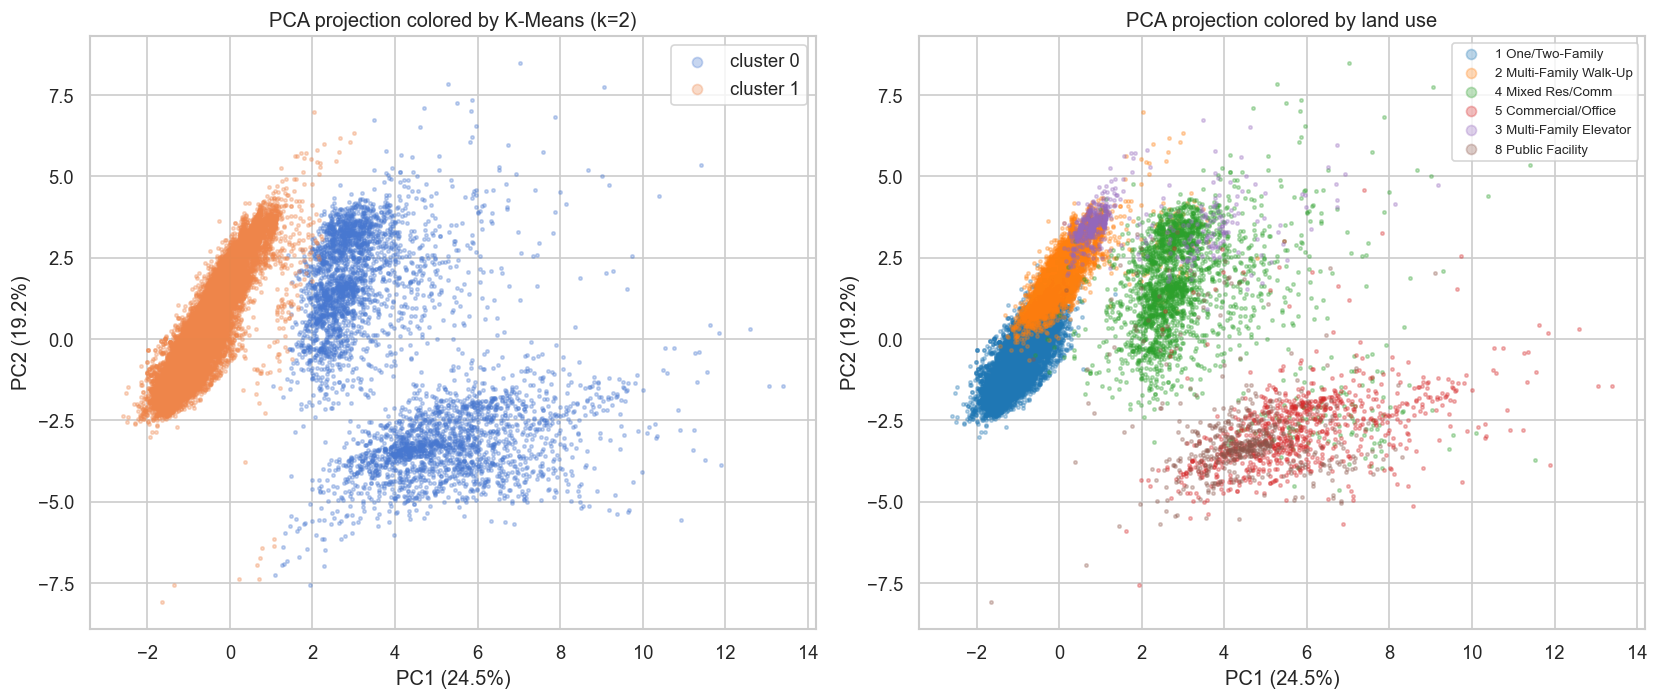

In [6]:
# Project onto the first two components.
X_pca2 = pca_full.transform(X)[:, :2]

# A reproducible random sample keeps the scatter readable (~682k points is too dense).
SCATTER_N = 30_000
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X), size=SCATTER_N, replace=False)

# Self-contained K-Means (k=2) for coloring - no dependency on external label files.
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X.iloc[idx])
clusters = km2.labels_

# PLUTO land-use codes -> human-readable names (interpretation only).
LANDUSE_NAMES = {
    1: "1 One/Two-Family", 2: "2 Multi-Family Walk-Up", 3: "3 Multi-Family Elevator",
    4: "4 Mixed Res/Comm", 5: "5 Commercial/Office", 6: "6 Industrial",
    7: "7 Transport/Utility", 8: "8 Public Facility", 9: "9 Open Space",
    10: "10 Parking", 11: "11 Vacant",
}
lu = companion["landuse"].iloc[idx].map(LANDUSE_NAMES).fillna("Unknown")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) colored by K-Means cluster
for c in np.unique(clusters):
    m = clusters == c
    axes[0].scatter(X_pca2[idx][m, 0], X_pca2[idx][m, 1], s=4, alpha=0.3, label=f"cluster {c}")
axes[0].set(xlabel=f"PC1 ({evr[0]*100:.1f}%)", ylabel=f"PC2 ({evr[1]*100:.1f}%)",
            title="PCA projection colored by K-Means (k=2)")
axes[0].legend(markerscale=3)

# (b) colored by the six most frequent land-use categories
top_lu = lu.value_counts().head(6).index
palette = dict(zip(top_lu, sns.color_palette("tab10", len(top_lu))))
for name in top_lu:
    m = (lu == name).values
    axes[1].scatter(X_pca2[idx][m, 0], X_pca2[idx][m, 1], s=4, alpha=0.3,
                    color=palette[name], label=name)
axes[1].set(xlabel=f"PC1 ({evr[0]*100:.1f}%)", ylabel=f"PC2 ({evr[1]*100:.1f}%)",
            title="PCA projection colored by land use")
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pca_scatter_2d.png", bbox_inches="tight")
plt.show()

To back the visual reading with numbers rather than the eye, we check how the two
clusters sit on the PC axes, and the mean PC1 of each land-use code.

In [7]:
# Quantify the geometry behind the scatter.
P3 = pca_full.transform(X)[:, :3]
pc1, pc2 = P3[idx, 0], P3[idx, 1]
rr = companion["residential_ratio"].iloc[idx].values
lu_code = companion["landuse"].iloc[idx].values

print("Mean position and residential_ratio per K-Means cluster:")
for c in np.unique(clusters):
    m = clusters == c
    print(f"  cluster {c}: n={m.sum():5d}  PC1={pc1[m].mean():+.2f}  PC2={pc2[m].mean():+.2f}"
          f"  residential_ratio={rr[m].mean():.3f}")
print(f"  -> clusters are separated mainly on PC1 "
      f"(|dPC1|={abs(pc1[clusters==0].mean()-pc1[clusters==1].mean()):.2f} "
      f"vs |dPC2|={abs(pc2[clusters==0].mean()-pc2[clusters==1].mean()):.2f})")

print("\nMean PC1 / PC2 per land-use code:")
for code_ in [1, 2, 3, 4, 5, 6, 7]:
    m = lu_code == code_
    if m.sum() > 50:
        print(f"  landuse {code_:2d} ({LANDUSE_NAMES[code_]:<22}): "
              f"n={m.sum():5d}  PC1={pc1[m].mean():+.2f}  PC2={pc2[m].mean():+.2f}")

Mean position and residential_ratio per K-Means cluster:
  cluster 0: n= 4588  PC1=+4.11  PC2=-0.45  residential_ratio=0.444
  cluster 1: n=25412  PC1=-0.75  PC2=+0.07  residential_ratio=0.998
  -> clusters are separated mainly on PC1 (|dPC1|=4.86 vs |dPC2|=0.52)

Mean PC1 / PC2 per land-use code:
  landuse  1 (1 One/Two-Family      ): n=19378  PC1=-1.00  PC2=-0.55
  landuse  2 (2 Multi-Family Walk-Up): n= 5536  PC1=+0.02  PC2=+1.97
  landuse  3 (3 Multi-Family Elevator): n=  574  PC1=+1.57  PC2=+3.50
  landuse  4 (4 Mixed Res/Comm      ): n= 2427  PC1=+3.06  PC2=+1.62
  landuse  5 (5 Commercial/Office   ): n=  870  PC1=+5.87  PC2=-2.75
  landuse  6 (6 Industrial          ): n=  414  PC1=+5.04  PC2=-3.68
  landuse  7 (7 Transport/Utility   ): n=  147  PC1=+5.14  PC2=-4.01


**Reading the projection.**

- The **K-Means k=2** boundary runs essentially along **PC1** (the cluster means differ
  by ~5 on PC1 but only ~0.5 on PC2). This confirms that the dominant binary divide the
  clustering found is the *residential vs non-residential* contrast PC1 encodes: the
  large cluster is ~100% residential (`residential_ratio` ~ 1.0), the smaller one is
  mixed/commercial (~0.44).
- The **land-use** coloring lines up with that geometry even though land use was never an
  input: single-family homes (code 1) sit at **low PC1**, while commercial, industrial
  and transport/utility lots (codes 5/6/7) sit at **high PC1**. Multi-family residential
  (codes 2/3) is instead separated along **PC2** (high residential intensity), exactly as
  the loadings predict. The discovered clusters therefore **agree with an external label**
  - a genuine validation rather than an artifact.
- The non-residential side spreads into a looser, more dispersed region, consistent with
  the "internal heterogeneity / two islands" observation noted in the clustering notebook.

## 5. Effect on clustering (full space vs PCA space)

The "Representation" section asks whether dimensionality reduction *helps* clustering.
We compare the silhouette score of **K-Means (k=2)** in:
- the full standardized **16D** space;
- the **PCA-reduced** space retaining 90% of the variance.

We follow the team's silhouette protocol (a 50k sample, `silhouette_score(...,
sample_size=10000, random_state=42)`) so the numbers are comparable to the clustering
notebook.

silhouette (k=2, Full 16D): 0.4752


silhouette (k=2, PCA 10D): 0.4812


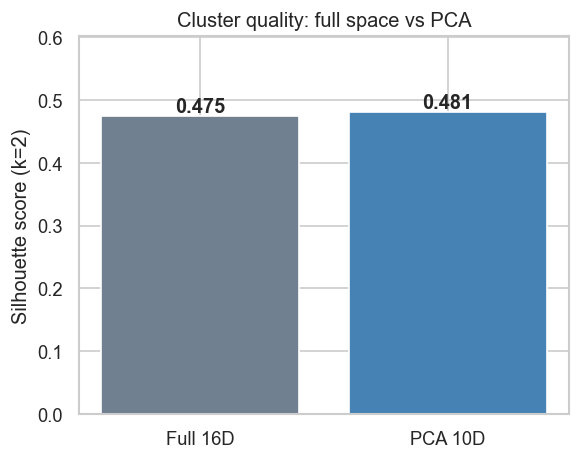

In [8]:
SAMPLE_N = 50_000
samp_idx = rng.choice(len(X), size=SAMPLE_N, replace=False)
X_samp = X.iloc[samp_idx].values

# PCA space retaining 90% of the variance.
X_pca_K90 = PCA(n_components=K90, random_state=RANDOM_STATE).fit_transform(X)
X_pca_samp = X_pca_K90[samp_idx]

results = {}
for name, M in [("Full 16D", X_samp), (f"PCA {K90}D", X_pca_samp)]:
    km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(M)
    s = silhouette_score(M, km.labels_, sample_size=10_000, random_state=RANDOM_STATE)
    results[name] = s
    print(f"silhouette (k=2, {name}): {s:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(list(results.keys()), list(results.values()), color=["slategray", "steelblue"])
for i, v in enumerate(results.values()):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")
ax.set(ylabel="Silhouette score (k=2)", title="Cluster quality: full space vs PCA",
       ylim=(0, max(results.values()) * 1.25))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pca_silhouette_comparison.png", bbox_inches="tight")
plt.show()

**Result.** The two silhouette scores are essentially identical (~0.47), with PCA
even marginally ahead thanks to mild denoising. So **PCA does not degrade cluster
quality** - it can be used as an optional preprocessing step without losing the k=2
structure. But because the gain is tiny and the space is already only 16-dimensional,
clustering directly in the full standardized space remains a perfectly valid choice.

## 6. Discussion and conclusions

**Mini-project questions (Part A).**

- *How quickly does the explained variance grow?* Slowly and steadily - no dominant
  direction, no sharp elbow. 90% requires 10 of 16 components.
- *What value of `k` seems reasonable?* `k = 10` for a 90% information budget, or `k = 2`
  purely for visualization. There is no strong compression sweet spot.
- *Is PCA useful for visualization, clustering, or compression?*
  - **Compression:** limited here (only 6 of 16 dimensions removed at 90%).
  - **Visualization:** yes - the 2D projection cleanly exposes the residential vs
    non-residential axis.
  - **Clustering:** neutral to slightly positive (silhouette unchanged), so it is a safe
    but not necessary preprocessing step.

**For the final report ("Representation").**

- **Method & parameters:** PCA on the standardized 16-feature matrix; retain 10
  components for the 90% variance budget, or 2 components for visualization.
- **Effect on clustering:** silhouette unchanged (~0.47, full vs PCA) - PCA preserves the
  cluster structure.
- **Effect on interpretability:** PC1-PC3 map onto interpretable building-morphology
  contrasts (residential/commercial, residential intensity, lot size vs density/age).
- **Advantages:** decorrelates correlated area features, denoises slightly, enables a
  meaningful 2D visualization that independently agrees with land use.
- **Limitations:** weak compression on this set; component signs are arbitrary; the 2D
  view shows only ~44% of the variance, so global distances must not be over-read.

**Recommendation.** Use PCA primarily as a **visualization and robustness tool** (color
the 2D projection by the clustering labels for the report), and keep the primary
clustering in the full standardized space - the two are equivalent on this dataset.
NMF is *not* directly applicable to `X_scaled` because standardization produces negative
values; it would require a non-negative representation and is left to its own notebook.